<a href="https://colab.research.google.com/github/DebjitHore/PyTorchLearning/blob/main/01_PyTorch%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Image 12-04-25 at 10.04 PM.jpg](attachment:355c42cd-91f7-44d4-a794-a7cd3cdc1e76.jpg)

In [25]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.6.0+cu124'

## Data (preparation and loading)

In [26]:
#linear regression based data creation : Y= a+bX
weight = 0.7 #b
bias = 0.3 #a

start=0
end=1
step = 0.02
X= torch.arange(start, end, step).unsqueeze(dim=1)
#X, X.ndim, X.shape
y=weight*X+bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [27]:
len(X), len(y)

(50, 50)

### Splitting data into training, validation and test set

In [28]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Visualizing train, test data

In [29]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  """
  Plots training data, test data & compares predictions
  """
  plt.figure(figsize=(10,7))
  #plot training data
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  #plot test data
  plt.scatter(test_data, test_labels, c="r", s=4, label="Test data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="g", label="Predictions")
  plt.legend(prop={"size" :14})


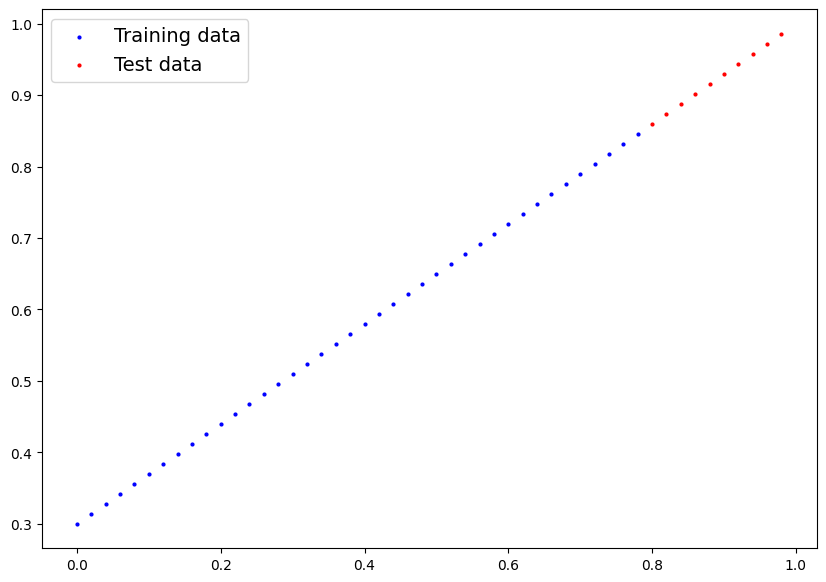

In [30]:
plot_predictions()

## Creating PyTorch model

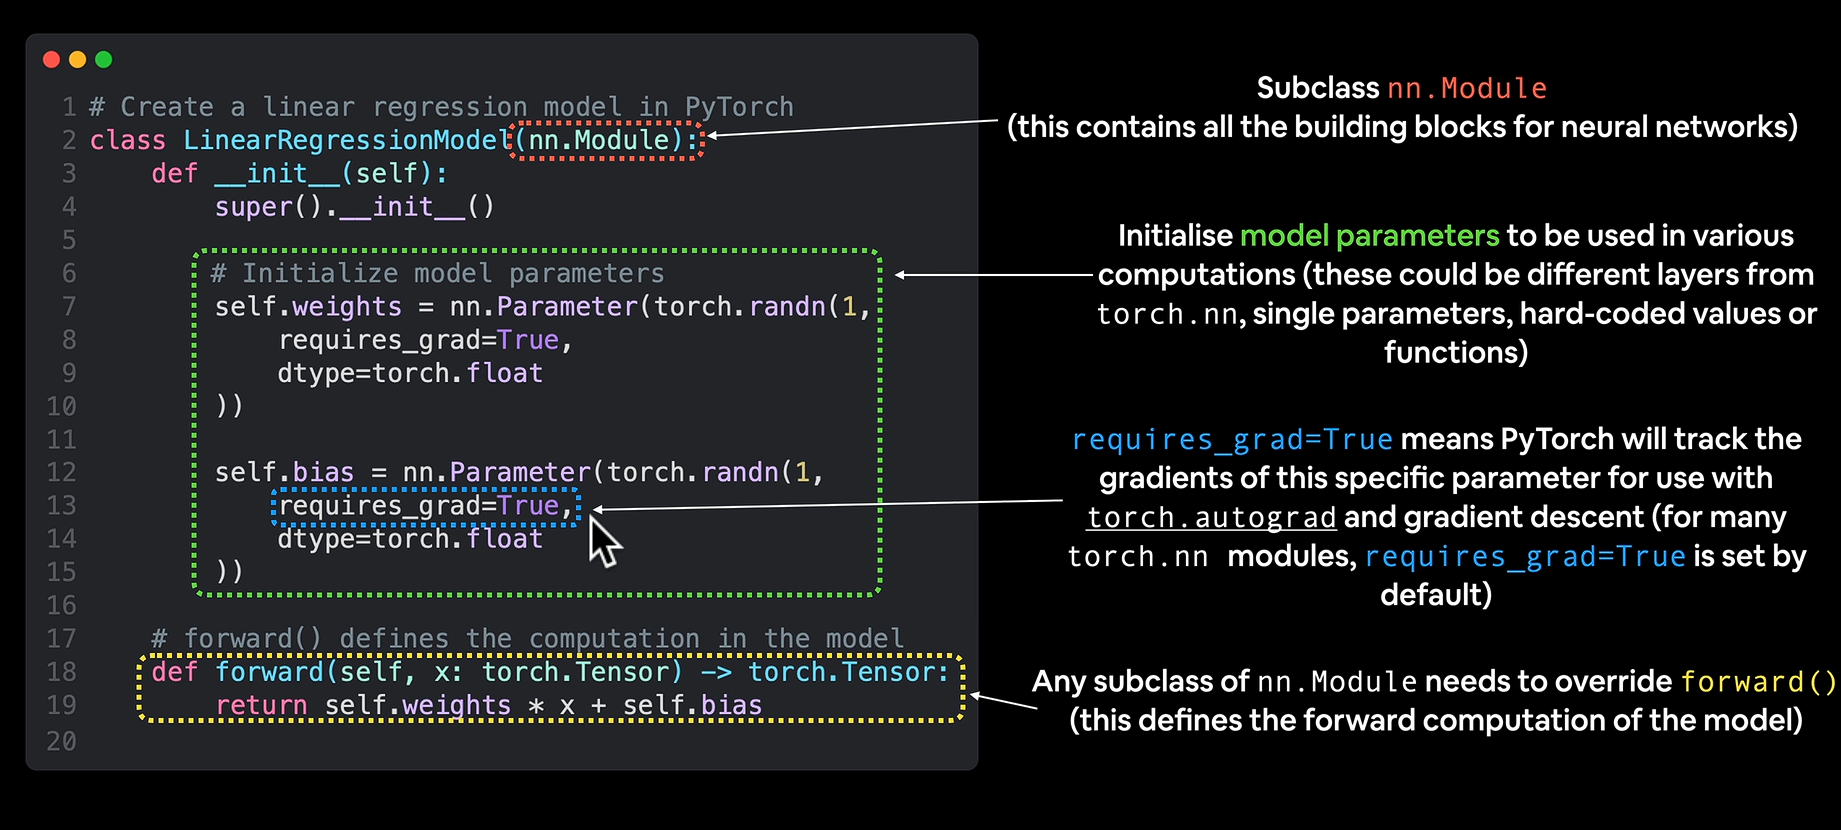

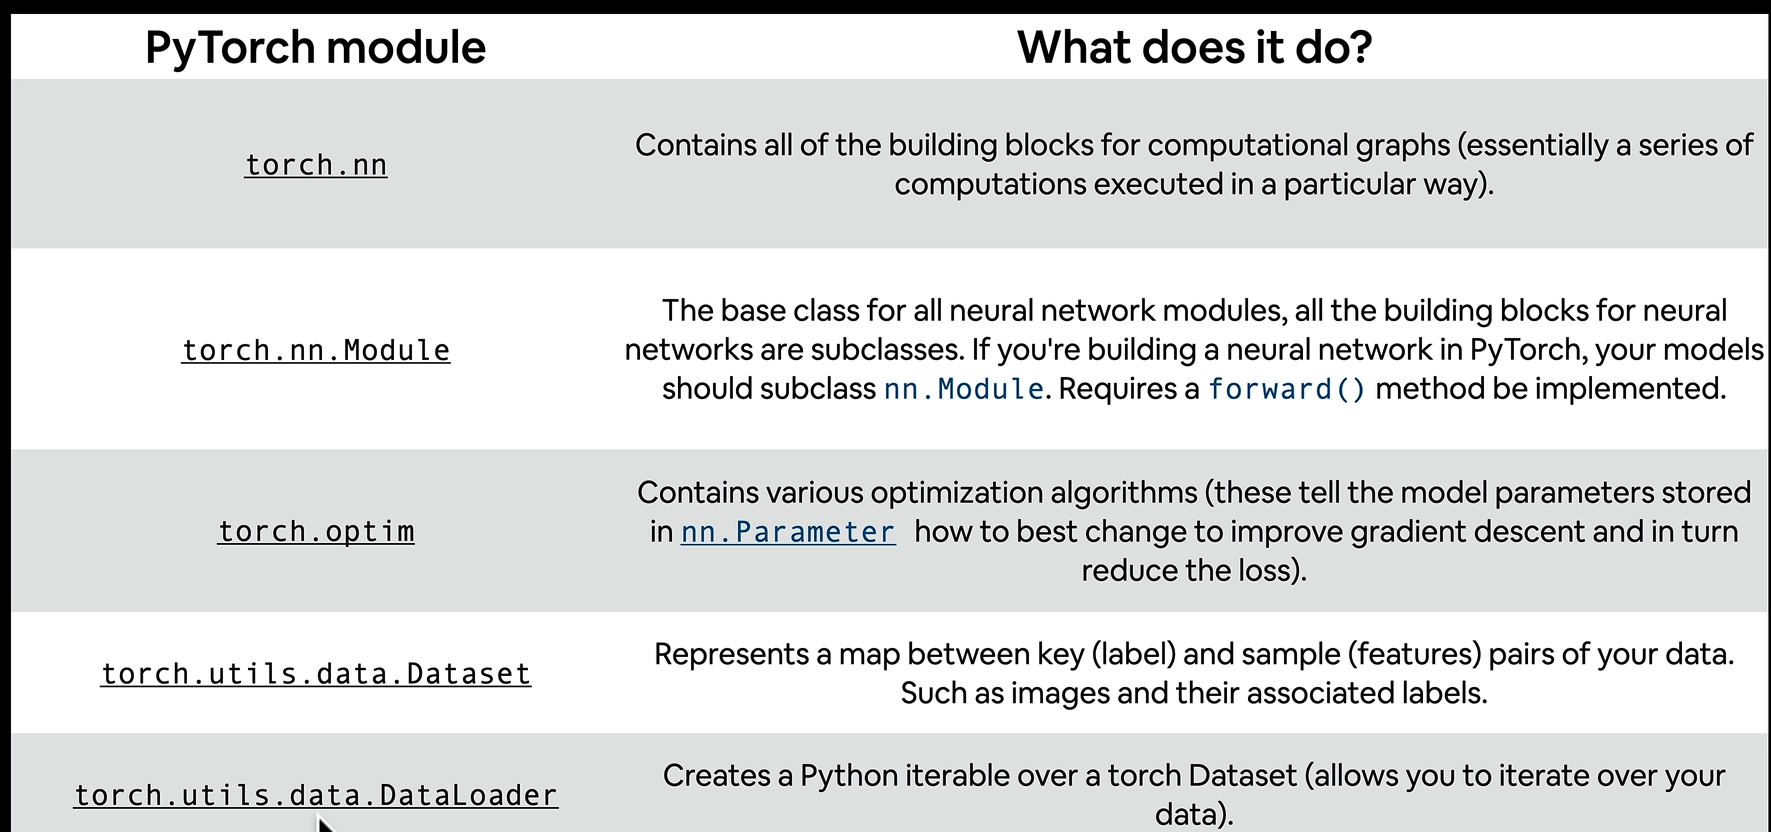

`PyTorch model building essentials`

* torch.nn - contains all model building essentials for computational graphs
* torch.nn.Parameter - parameters that the model should try and learn, often a PyTorch layer from torch.nn will set these
* torch.nn.Module - base class for all neural networks modules, if you subclass it, write own forward( )
* torch.optim - optimizer in PyTorch
* def forward( ) - All nn.Module subclasses

In [32]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))

    #forward propagation

    def forward (self, x :torch.Tensor) -> torch.Tensor:
      return self.weights*x+self.bias #linear regression

